In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as stats

#Import Libraries

## First lets read in the raw file

In [2]:
poke_df= pd.read_csv('/Users/empressb/PortfolioProject1Pokemon/data/raw/pokemon_data.csv')
poke_df.head()

,id,name,height,weight,type_1,type_2,hp,attack,defense,special_attack,special_defense,speed,base_stat_total
0,1,bulbasaur,7,69,grass,poison,45,49,49,65,65,45,318
1,2,ivysaur,10,130,grass,poison,60,62,63,80,80,60,405
2,3,venusaur,20,1000,grass,poison,80,82,83,100,100,80,525
3,4,charmander,6,85,fire,NaN,39,52,43,60,50,65,309
4,5,charmeleon,11,190,fire,NaN,58,64,58,80,65,80,405


In [3]:
poke_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               1025 non-null   int64 
 1   name             1025 non-null   object
 2   height           1025 non-null   int64 
 3   weight           1025 non-null   int64 
 4   type_1           1025 non-null   object
 5   type_2           526 non-null    object
 6   hp               1025 non-null   int64 
 7   attack           1025 non-null   int64 
 8   defense          1025 non-null   int64 
 9   special_attack   1025 non-null   int64 
 10  special_defense  1025 non-null   int64 
 11  speed            1025 non-null   int64 
 12  base_stat_total  1025 non-null   int64 
dtypes: int64(10), object(3)
memory usage: 104.2+ KB


## How many rows and columns are in this dataset?


In [6]:
poke_df.shape




(1025, 13)

## What does the descriptive analysis look like in this dataset?

In [7]:
poke_df.describe()

,id,height,weight,hp,attack,defense,special_attack,special_defense,speed,base_stat_total
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,513.000000,12.116098,669.870244,70.184390,77.521951,72.507317,70.080976,70.205854,67.186341,427.686829
std,296.036315,12.481673,1212.728543,26.631054,29.782541,29.286972,29.658378,26.639329,28.717227,112.770735
min,1.000000,1.000000,1.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,175.000000
25%,257.000000,5.000000,85.000000,50.000000,55.000000,50.000000,47.000000,50.000000,45.000000,325.000000
50%,513.000000,10.000000,280.000000,68.000000,75.000000,70.000000,65.000000,67.000000,65.000000,450.000000
75%,769.000000,15.000000,700.000000,85.000000,100.000000,90.000000,90.000000,86.000000,88.000000,508.000000
max,1025.000000,200.000000,9999.000000,255.000000,181.000000,230.000000,173.000000,230.000000,200.000000,720.000000


## Now for some light exploratory data analysis

### 1. Is there a relationship between weight and base stat total?

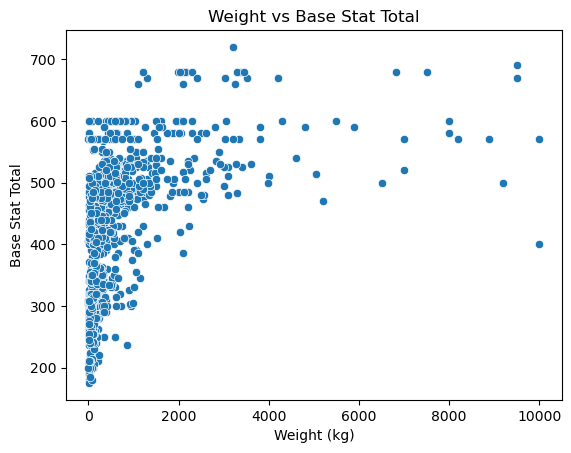

In [8]:
##Is there a correlation between weight and base stat total?
plt.figure
sns.scatterplot(x='weight', y='base_stat_total', data=poke_df)
plt.title('Weight vs Base Stat Total')
plt.xlabel('Weight (kg)')
plt.ylabel('Base Stat Total')
plt.show()

In [9]:
correlation = poke_df['weight'].corr(poke_df['base_stat_total'])
print(f'Correlation between weight and base stat total: {correlation:.2f}')

Correlation between weight and base stat total: 0.46


### To answer my question- Yes, there is a moderate positive correlation(r=0.46), meaning heavier Pokemon tend to have higher base stat totals, but weight along is not a strong or reliable predictor.  There is a heavy skew which hides the trend visually.

### 2. Do Pokemon with second-type have a higher base stat total than single-type Pokemon?

In [10]:
poke_df['Dual_Type'] = poke_df['type_2'].notna()
type_counts = poke_df['Dual_Type'].value_counts()
plt.figure(figsize=(6, 4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

In [12]:
diff_types=(
    poke_df.groupby(['Dual_Type']).mean()
    .reset_index()
    .sort_values('base_stat_total', ascending=False)

)

diff_types

,Dual_Type,id,height,weight,hp,attack,defense,special_attack,special_defense,speed,base_stat_total
1,True,544.602662,13.551331,778.355513,72.657795,81.176806,77.427757,75.129278,74.207224,70.429658,451.028517
0,False,479.687375,10.603206,555.515030,67.577154,73.669339,67.320641,64.759519,65.987976,63.767535,403.082164
